# Lab 2 — Digital Image Fundamentals
**Course:** ARTI407 – Image Processing  
**College of Computer Science and Information Technology**  
**Imam Abdulrahman Bin Faisal University**

This notebook covers the lab manual:
1. **Sampling and Quantization**
2. **Arithmetic Operations** (add, subtract, add constant)
3. **Set / Logical Operations** (union, intersection, difference, symmetric difference)
4. **Practical Tasks**

> **Note on images:** The lab references `lena_gray_256.tif`, `cameraman.tif`, `A.png`, `B.png`. Since those files aren't bundled with the notebook, this notebook uses built-in `skimage` images so every cell runs out of the box. To use your own image, just replace the loading line.

digital image ia a image consist of pixels 
and we need to convert the normal image to digtal to make computer easy deal and process it 

## Setup

In [1]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install scikit-image

Note: you may need to restart the kernel to use updated packages.


In [3]:
import cv2 # computer vision --> store the images as array , and its have a lot of functions we can use it
import numpy as np
from PIL import Image # store the image as a normal image
from skimage import data # skimage have  a module very useful called  data have a lot of image and we can use it
import matplotlib.pyplot as plt # print the image 

%matplotlib inline

---
## Section 1 — Image Sampling and Quantization

- **Sampling** = how many pixels we keep (spatial resolution).
- **Quantization** = how many gray levels we keep (intensity resolution).

sampling نختار وش البكسل اللي بناخذها ومن لا 
quantizationو 255 ابيض نحدد رقم لكل بكسل لان الرينج من صفر الى 255 وهذا يعني بلاك0

In [4]:
def sample_image(image, factor): # factor --> we want to Downsamples by what?
    """Downsamples the image by the given factor."""
    height, width = image.shape[:2]
    # do a sampling 
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST) #resize will take the image and do an operation 
    return sampled_image
#interpolation-->when we have an arrray 4*4 and we want to reduce the size ,

def quantize_image(image, levels):
    """Reduces the number of grayscale levels in the image."""
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels) # 256 is a gray level which is from 0 to 255 = 256 
    # np.floor --> round down 
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized): # will take the original image and the small image and the darkn image 
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1), plt.imshow(original, cmap='gray')
    plt.title('Original Image'), plt.axis('off')
    plt.subplot(1, 3, 2), plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image'), plt.axis('off')
    plt.subplot(1, 3, 3), plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image'), plt.axis('off')
    plt.show()

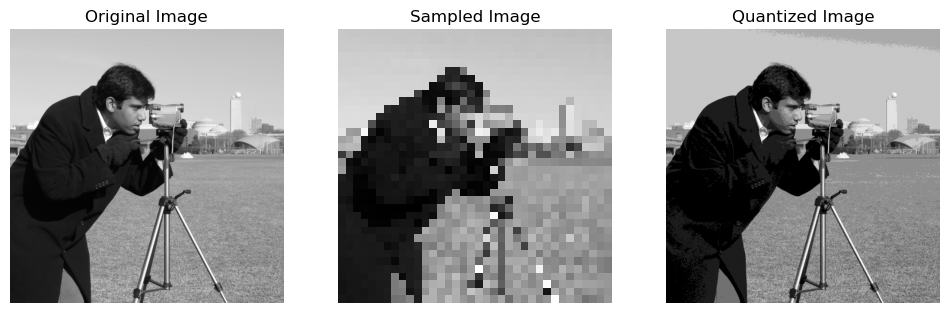

In [5]:
original_image = data.camera() # use the image from skimage

sampling_factor = 14# ابغا اصغر الصوره باي 14
quantization_levels = 9 # حددت درجه اللون اللي ابغاه 

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image)

---
## Section 2 — Arithmetic Operations

Add two images by converting them to numpy arrays and adding element-wise.

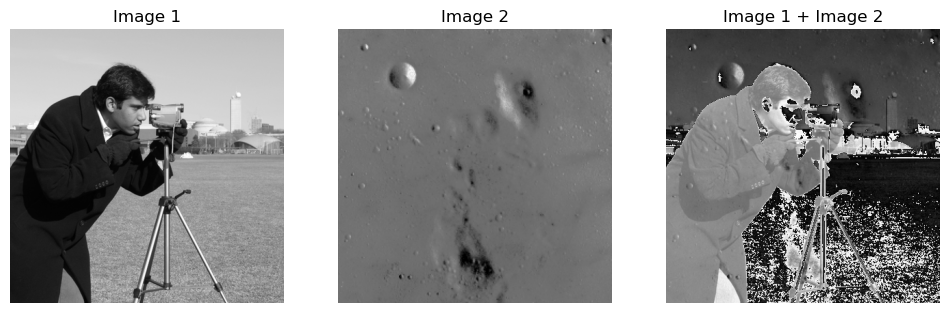

In [6]:
# arithmatic op have 4 steps 
# convert the arrays to normal image because we want to use resize function 
img1 = Image.fromarray(data.camera())
img2 = Image.fromarray(data.moon())

new_size = (400, 400) # احنا نعرفه
img1 = img1.resize(new_size, Image.Resampling.LANCZOS)# Resampling.LANCZOS افضل من ال interpolation 
img2 = img2.resize(new_size, Image.Resampling.LANCZOS)
# now convert the images to array because we want to add them
im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

addition = im1arr + im2arr
result_image = Image.fromarray(addition)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img1, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img2, cmap='gray'), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 1 + Image 2'), plt.axis('off')
plt.show()

---
## Section 3 — Set / Logical Operations

Pixel-wise bitwise operations on two images. Lab demo: **union (OR)**.

we can add and sub the image because the images are array 


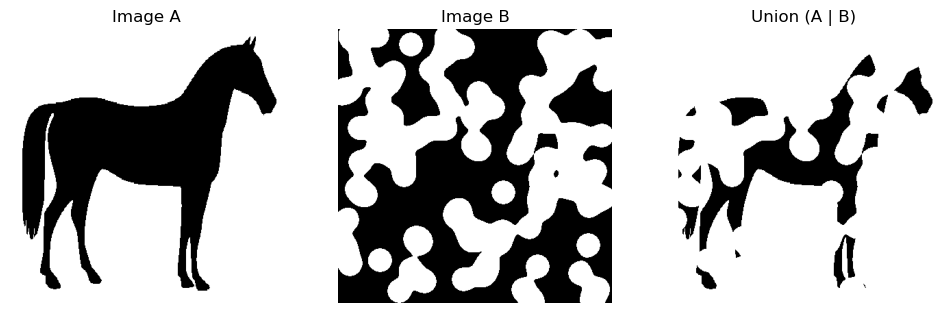

In [7]:

img3 = Image.fromarray(data.horse())
img4 = Image.fromarray(data.binary_blobs(length=400))

img3 = img3.resize(new_size, Image.Resampling.LANCZOS)
img4 = img4.resize(new_size, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
result_image_2 = Image.fromarray(union)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img3, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img4, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image_2, cmap='gray'), plt.title('Union (A | B)'), plt.axis('off')
plt.show()

---
# Practical Tasks

## Task 1 — Change sampling and quantization parameters and observe the effects

Try multiple values of the sampling factor and the number of quantization levels to see how each affects the image.

### 1a) Effect of sampling factor (spatial resolution)

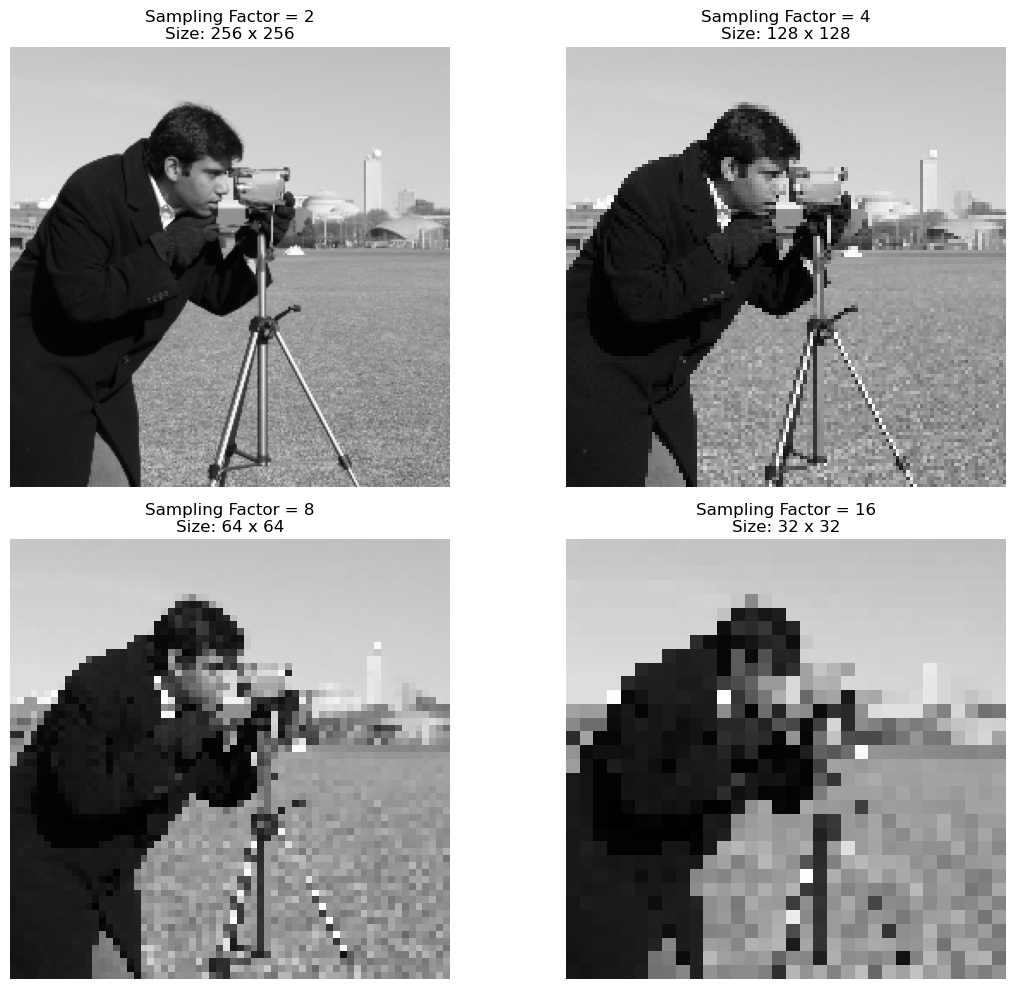

Observation: As the sampling factor increases, the image contains fewer pixels and loses spatial detail.


In [9]:

sampling_factors = [2, 4, 8, 16]

plt.figure(figsize=(12, 10))

for i, factor in enumerate(sampling_factors, 1):
    sampled = sample_image(original_image, factor)

    plt.subplot(2, 2, i)
    plt.imshow(sampled, cmap='gray')
    plt.title(
        f'Sampling Factor = {factor}\n'
        f'Size: {sampled.shape[1]} x {sampled.shape[0]}'
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

print(
    "Observation: As the sampling factor increases, "
    "the image contains fewer pixels and loses spatial detail."
)

### 1b) Effect of quantization levels (intensity resolution)

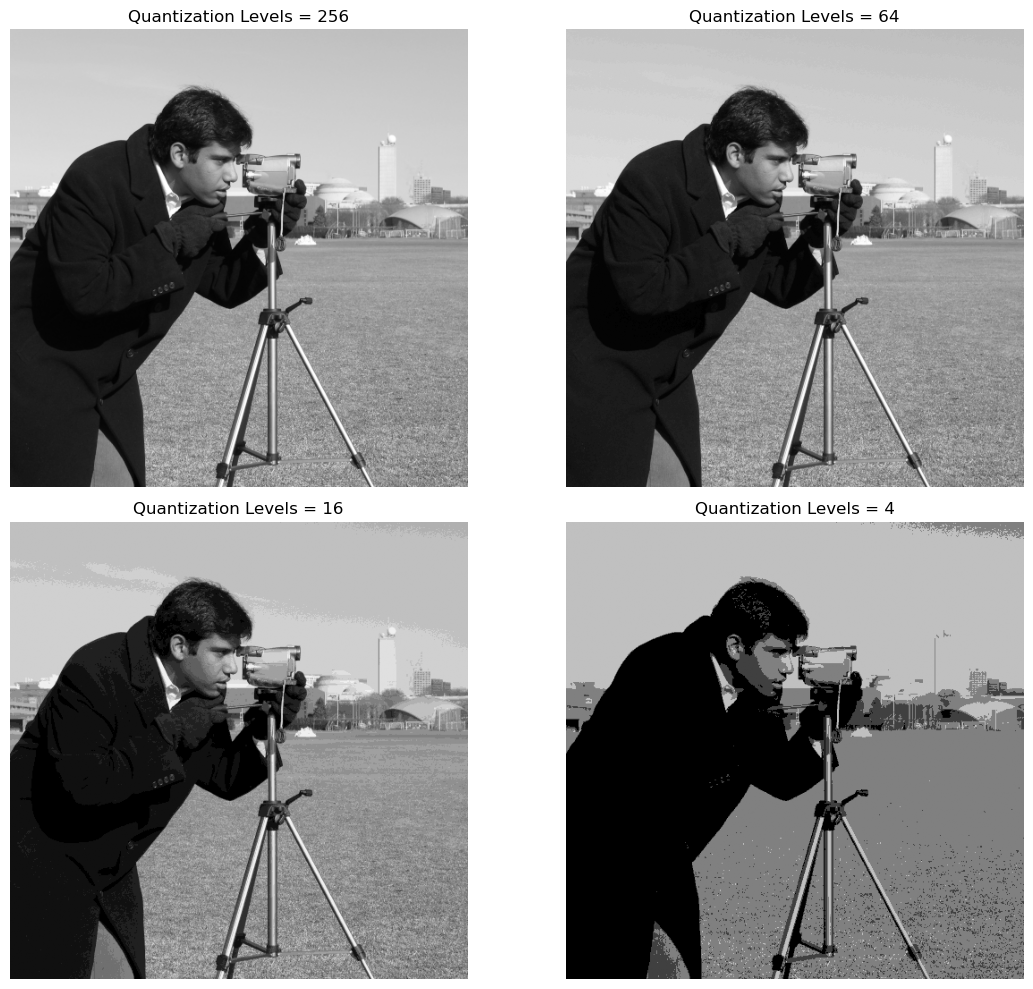

Observation: Reducing the number of quantization levels decreases intensity resolution and produces visible banding/posterization.


In [10]:
# Task 1b — Effect of Quantization Levels

quantization_levels_list = [256, 64, 16, 4]

plt.figure(figsize=(12, 10))

for i, levels in enumerate(quantization_levels_list, 1):
    quantized = quantize_image(original_image, levels)

    plt.subplot(2, 2, i)
    plt.imshow(quantized, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Quantization Levels = {levels}')
    plt.axis('off')

plt.tight_layout()
plt.show()

print(
    "Observation: Reducing the number of quantization levels "
    "decreases intensity resolution and produces visible banding/posterization."
)

---
## Task 2 — Image Arithmetic and Set Operations

Required operations:
1. Subtract two images and display the result
2. Add one image with a constant value 175
3. Set difference on two grayscale images
4. Symmetric difference on two grayscale images
5. Intersection on two grayscale images

### 2a) Subtract two images

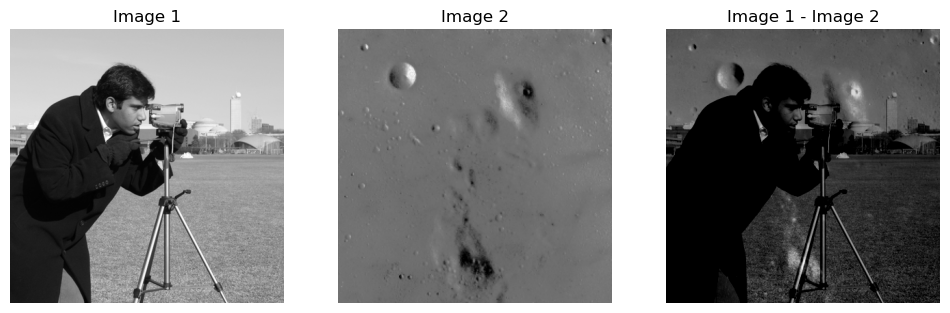

In [11]:
# Task 2a — Subtract Two Images

img1 = Image.fromarray(data.camera()).resize(
    new_size,
    Image.Resampling.LANCZOS
)

img2 = Image.fromarray(data.moon()).resize(
    new_size,
    Image.Resampling.LANCZOS
)

im1arr = np.asarray(img1, dtype=np.uint8)
im2arr = np.asarray(img2, dtype=np.uint8)

subtraction = cv2.subtract(im1arr, im2arr)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(im1arr, cmap='gray')
plt.title('Image 1')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(im2arr, cmap='gray')
plt.title('Image 2')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(subtraction, cmap='gray')
plt.title('Image 1 - Image 2')
plt.axis('off')

plt.show()

### 2b) Add image with constant value 175

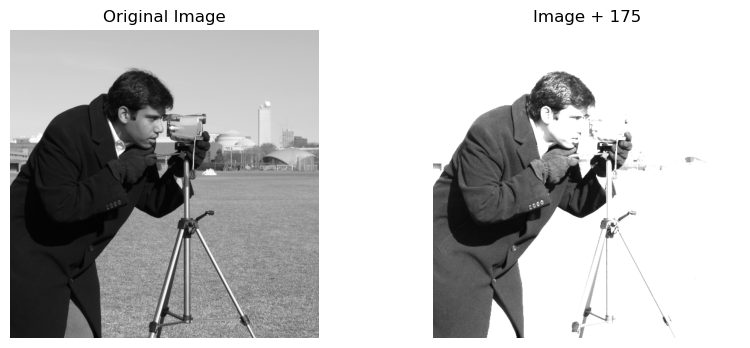

In [12]:
# Task 2b — Add Image with Constant Value 175

image = data.camera().astype(np.uint8)

constant = 175

added_constant = cv2.add(
    image,
    np.full_like(image, constant)
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(added_constant, cmap='gray')
plt.title('Image + 175')
plt.axis('off')

plt.show()

### 2c-2e) Set operations on grayscale images

| Operation | Bitwise formula | Meaning |
|---|---|---|
| **Intersection** | `A & B` | bits set in both |
| **Set difference** | `A & ~B` (A − B) | bits in A but not in B |
| **Symmetric difference** | `A ^ B` | bits in A or B but not both |
| **Union** (extra) | `A \| B` | bits in either |

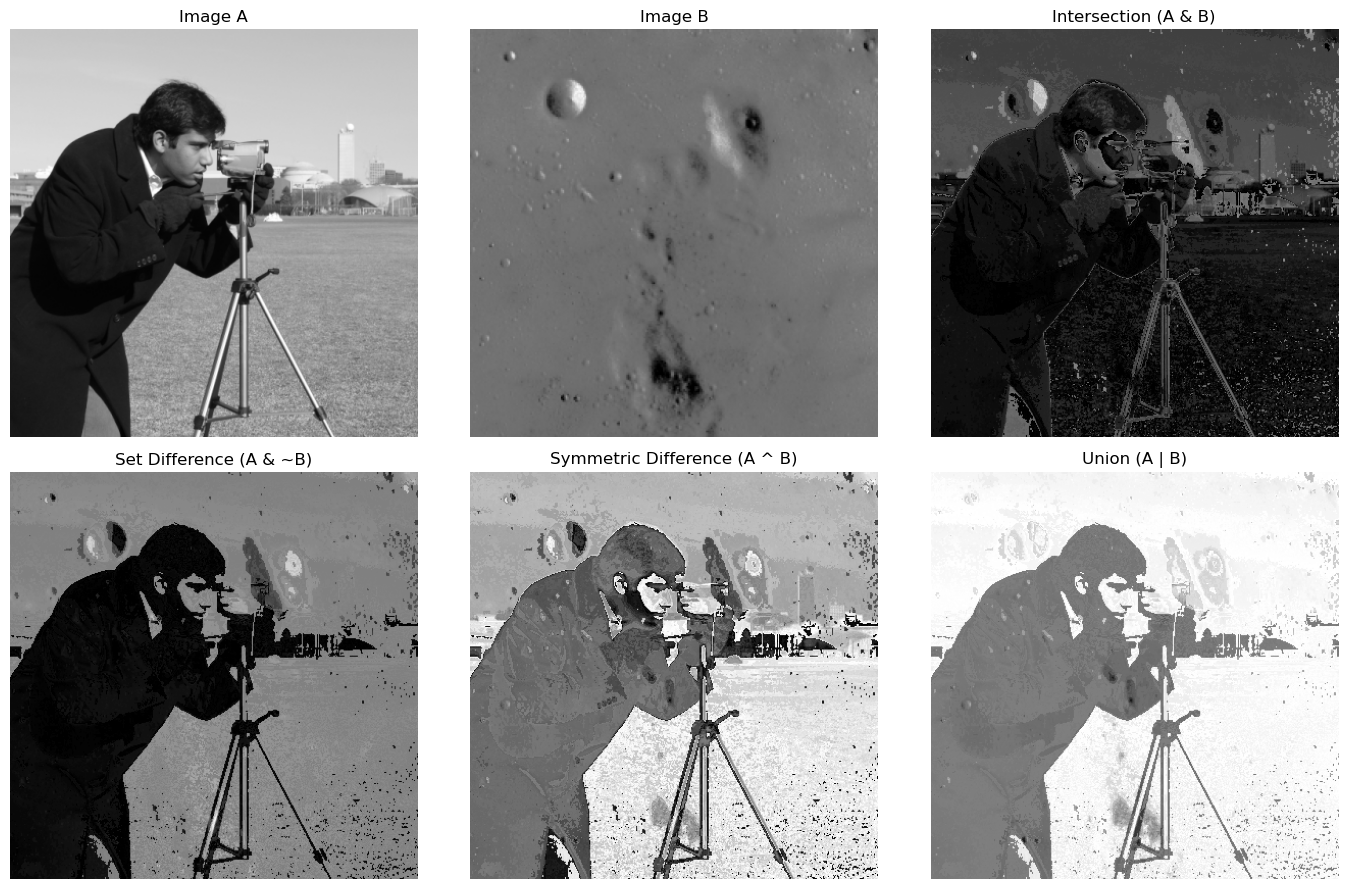

In [13]:
# Task 2c, 2d, 2e — Set Operations

A = cv2.resize(
    data.camera(),
    new_size,
    interpolation=cv2.INTER_AREA
).astype(np.uint8)

B = cv2.resize(
    data.moon(),
    new_size,
    interpolation=cv2.INTER_AREA
).astype(np.uint8)


# Intersection
intersection = cv2.bitwise_and(A, B)


# Set Difference A - B
set_difference = cv2.bitwise_and(
    A,
    cv2.bitwise_not(B)
)


# Symmetric Difference
symmetric_difference = cv2.bitwise_xor(A, B)


# Union
union = cv2.bitwise_or(A, B)


titles = [
    'Image A',
    'Image B',
    'Intersection (A & B)',
    'Set Difference (A & ~B)',
    'Symmetric Difference (A ^ B)',
    'Union (A | B)'
]

images = [
    A,
    B,
    intersection,
    set_difference,
    symmetric_difference,
    union
]

plt.figure(figsize=(14, 9))

for i, (img, title) in enumerate(zip(images, titles), 1):

    plt.subplot(2, 3, i)

    plt.imshow(
        img,
        cmap='gray',
        vmin=0,
        vmax=255
    )

    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()